# **Churn Prediction: Customer Telco**

## 1. Exploring and loading the data

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Dataset_Churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Cleaning the data

In [48]:
# Nulls analysis
print("Nulls per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicates:", df['customerID'].duplicated().sum())

print("\nBlank values in TotalCharges:")
blank_mask = df['TotalCharges'].str.strip() == ''
print(blank_mask.sum())
print(df[blank_mask][['customerID', 'tenure', 'TotalCharges']])

Nulls per column:
Series([], dtype: int64)

Duplicates: 0

Blank values in TotalCharges:
11
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


In [49]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Fill the newly created NaNs with 0
# (customers with tenure=0 haven't accrued any charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify there are no nulls left and the data type is numeric
print("Nulls after cleaning:", df['TotalCharges'].isnull().sum())
print("Data type:", df['TotalCharges'].dtype)

Nulls after cleaning: 0
Data type: float64


## 3. Exploratory analysis - Churn by variable

We visualize how the cancellation rate (`Churn`) is distributed across the most relevant variables: contract type, internet service, payment method and tenure.

## Font and color setup

In [50]:
import urllib.request
from pathlib import Path
from matplotlib import font_manager
import matplotlib.pyplot as plt

# Download the Raleway font directly from the official Google Fonts repository
# and register it in matplotlib without needing to install it on Windows
font_url = "https://github.com/google/fonts/raw/main/ofl/raleway/Raleway%5Bwght%5D.ttf"
font_path = Path("raleway.ttf")
urllib.request.urlretrieve(font_url, font_path)

# Register the font in matplotlib and set it as default
font_manager.fontManager.addfont(str(font_path))
plt.rcParams['font.family'] = 'Raleway'

print("Raleway font loaded successfully")

# S3 Analytics brand palette (used across all charts)
S3_TEAL = '#2dd4bf'
S3_RED = '#ef4444'
S3_AMBER = '#f0b429'
S3_GREEN = '#22c55e'
S3_BG = '#0b1120'
S3_TEXT = '#e6edf3'

Raleway font loaded successfully


findfont: Failed to find font weight normal, now using 100.
C:\Users\sebas\AppData\Local\Temp\ipykernel_35276\3689032633.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.countplot(data=df, x='Churn', ax=axes[0], palette=[S3_TEAL, S3_RED])
findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight bold, now using 100.
findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight bold, now using 100.


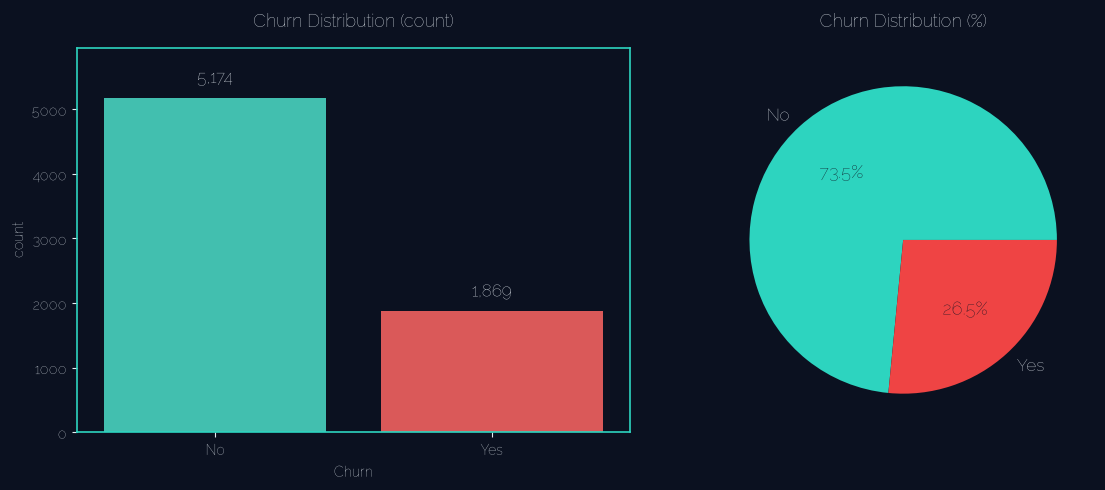

In [51]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(S3_BG)

# --- Bar chart ---
bars = sns.countplot(data=df, x='Churn', ax=axes[0], palette=[S3_TEAL, S3_RED])
axes[0].set_title('Churn Distribution (count)', color=S3_TEXT, fontsize=13, pad=15)
axes[0].set_facecolor(S3_BG)
axes[0].tick_params(colors=S3_TEXT)
axes[0].xaxis.label.set_color(S3_TEXT)
axes[0].yaxis.label.set_color(S3_TEXT)
# Marco del gráfico de barras
for spine in axes[0].spines.values():
    spine.set_color('#2dd4bf')
    spine.set_linewidth(1.2)
axes[0].set_ylim(0, max(churn_counts) * 1.15)

for p in bars.patches:
    height = p.get_height()
    axes[0].annotate(
        f'{int(height):,}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=12, color=S3_TEXT, fontweight='bold',
        xytext=(0, 8), textcoords='offset points'
    )

# --- Pie chart ---
wedges, texts, autotexts = axes[1].pie(
    churn_pct,
    labels=churn_pct.index,
    autopct='%1.1f%%',
    colors=[S3_TEAL, S3_RED],
    textprops={'color': S3_TEXT, 'fontsize': 12},
)

# Hace los números del pie más grandes y visibles
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
    autotext.set_color(S3_BG)  # texto oscuro sobre el color de cada sector



axes[1].set_title('Churn Distribution (%)', color=S3_TEXT, fontsize=13, pad=15)

plt.tight_layout()
plt.savefig('../data/churn_dist.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 4. Churn by key variables

We analyze the variables with the highest predictive power identified in the initial EDA: contract type, internet service, payment method and tech support.

### Contract Type - the strongest predictor

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


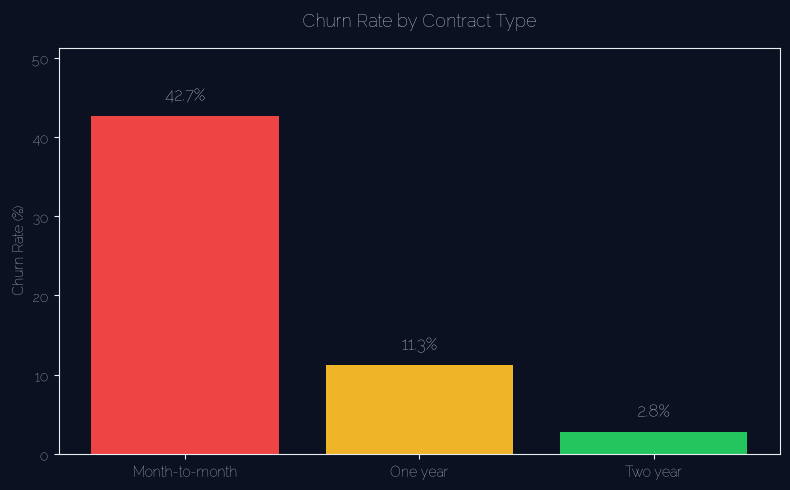

In [52]:
# Calculate churn rate (mean of 0/1) and customer count by contract type
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

print(churn_by_contract.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(S3_BG)
ax.set_facecolor(S3_BG)

colors_map = [S3_RED, S3_AMBER, S3_GREEN]
bars = ax.bar(churn_by_contract.index, churn_by_contract.values, color=colors_map)

ax.set_title('Churn Rate by Contract Type', color=S3_TEXT, fontsize=13, pad=15)
ax.set_ylabel('Churn Rate (%)', color=S3_TEXT)
ax.tick_params(colors=S3_TEXT)
for spine in ax.spines.values():
    spine.set_color(S3_TEXT)
ax.set_ylim(0, max(churn_by_contract.values) * 1.2)

for bar, val in zip(bars, churn_by_contract.values):
    ax.annotate(
        f'{val:.1f}%',
        (bar.get_x() + bar.get_width() / 2, val),
        ha='center', va='bottom',
        fontsize=12, color=S3_TEXT, fontweight='bold',
        xytext=(0, 8), textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('../data/churn_contract.png', dpi=150, bbox_inches='tight', facecolor='white')  # ← antes del show
plt.show()

### Internet Service and Payment Method

findfont: Failed to find font weight bold, now using 100.


Churn by Internet Service:
 InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64

Churn by Payment Method:
 PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64


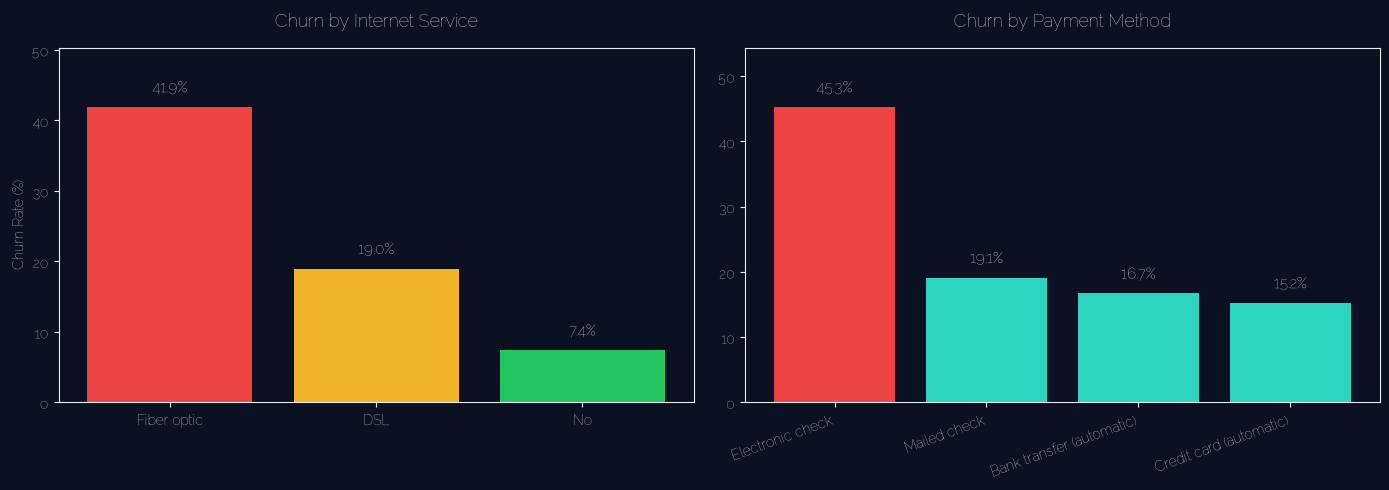

In [53]:
# Calculate churn rate by Internet Service and by Payment Method
churn_by_internet = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

churn_by_payment = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

print("Churn by Internet Service:\n", churn_by_internet.round(1))
print("\nChurn by Payment Method:\n", churn_by_payment.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(S3_BG)

# --- Chart 1: Internet Service ---
ax = axes[0]
ax.set_facecolor(S3_BG)
colors1 = [S3_RED, S3_AMBER, S3_GREEN]
bars1 = ax.bar(churn_by_internet.index, churn_by_internet.values, color=colors1)
ax.set_title('Churn by Internet Service', color=S3_TEXT, fontsize=13, pad=15)
ax.set_ylabel('Churn Rate (%)', color=S3_TEXT)
ax.tick_params(colors=S3_TEXT)
for spine in ax.spines.values():
    spine.set_color(S3_TEXT)
ax.set_ylim(0, max(churn_by_internet.values) * 1.2)
for bar, val in zip(bars1, churn_by_internet.values):
    ax.annotate(f'{val:.1f}%', (bar.get_x() + bar.get_width()/2, val),
                ha='center', va='bottom', fontsize=11, color=S3_TEXT,
                fontweight='bold', xytext=(0, 8), textcoords='offset points')

# --- Chart 2: Payment Method ---
ax = axes[1]
ax.set_facecolor(S3_BG)
# 4 categories, teal for lower-risk ones and red for the high-risk one
colors2 = [S3_RED if v > 30 else S3_TEAL for v in churn_by_payment.values]
bars2 = ax.bar(range(len(churn_by_payment)), churn_by_payment.values, color=colors2)
ax.set_title('Churn by Payment Method', color=S3_TEXT, fontsize=13, pad=15)
ax.set_xticks(range(len(churn_by_payment)))
ax.set_xticklabels(churn_by_payment.index, rotation=20, ha='right')
ax.tick_params(colors=S3_TEXT)
for spine in ax.spines.values():
    spine.set_color(S3_TEXT)
ax.set_ylim(0, max(churn_by_payment.values) * 1.2)
for bar, val in zip(bars2, churn_by_payment.values):
    ax.annotate(f'{val:.1f}%', (bar.get_x() + bar.get_width()/2, val),
                ha='center', va='bottom', fontsize=11, color=S3_TEXT,
                fontweight='bold', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

### Tenure y Monthly Charges - Churned vs Active

We compared the distribution of tenure and monthly salary between customers who left and those who stayed.

C:\Users\sebas\AppData\Local\Temp\ipykernel_35276\132641123.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax,
C:\Users\sebas\AppData\Local\Temp\ipykernel_35276\132641123.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax,


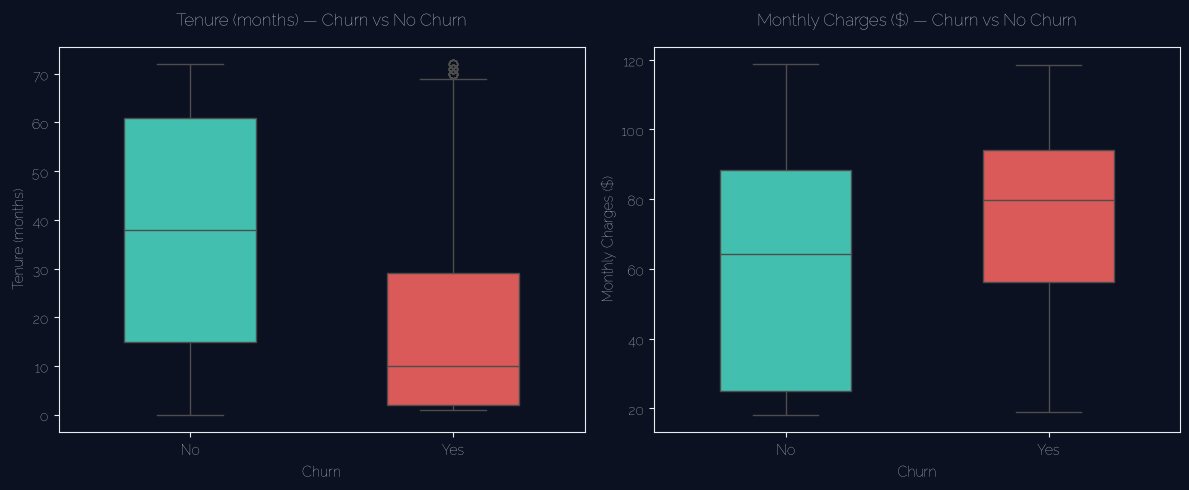

Tenure by Churn:
       mean   50%   std
Churn                  
No     37.6  38.0  24.1
Yes    18.0  10.0  19.5

MonthlyCharges by Churn:
       mean   50%   std
Churn                  
No     61.3  64.4  31.1
Yes    74.4  79.6  24.7


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(S3_BG)

for ax, col, title in zip(axes, ['tenure', 'MonthlyCharges'], 
                            ['Tenure (months)', 'Monthly Charges ($)']):
    ax.set_facecolor(S3_BG)
    
    # Boxplot: compares the distribution of the numeric variable split by Churn
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, 
                palette=[S3_TEAL, S3_RED], width=0.5)
    
    ax.set_title(f'{title} — Churn vs No Churn', color=S3_TEXT, fontsize=12, pad=15)
    ax.set_xlabel('Churn', color=S3_TEXT)
    ax.set_ylabel(title, color=S3_TEXT)
    ax.tick_params(colors=S3_TEXT)
    for spine in ax.spines.values():
        spine.set_color(S3_TEXT)

plt.tight_layout()
plt.show()

# Numeric summary below the chart
print("Tenure by Churn:")
print(df.groupby('Churn')['tenure'].describe()[['mean','50%','std']].round(1))
print("\nMonthlyCharges by Churn:")
print(df.groupby('Churn')['MonthlyCharges'].describe()[['mean','50%','std']].round(1))

## 5. Feature Engineering

We prepare the data for modeling:
- Drop non-predictive columns (`customerID`)
- Create `tenure_group` to capture the non-linear relationship seen in the EDA
- Encode categorical variables with One-Hot Encoding
- Split into training and test sets (80/20)

In [55]:
# Create a copy so we don't modify the original df (good practice)
df_model = df.copy()

# Drop customerID — it's a unique identifier, carries no predictive information
df_model = df_model.drop(columns=['customerID'])

# Create tenure groups (tenure_group)
# This helps the model capture the non-linear relationship we saw in the boxplot:
# churn risk drops sharply in the first months and then stabilizes
def tenure_group(t):
    if t <= 12: return '0-12'
    elif t <= 24: return '13-24'
    elif t <= 48: return '25-48'
    else: return '49-72'

df_model['tenure_group'] = df_model['tenure'].apply(tenure_group)

# Convert the Churn target from text (Yes/No) to number (1/0)
# This is required: classification models need a numeric target
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

print("Shape after cleanup:", df_model.shape)
print("\ntenure_group distribution:")
print(df_model['tenure_group'].value_counts())
print("\nTarget (Churn) distribution:")
print(df_model['Churn'].value_counts())

Shape after cleanup: (7043, 21)

tenure_group distribution:
tenure_group
49-72    2239
0-12     2186
25-48    1594
13-24    1024
Name: count, dtype: int64

Target (Churn) distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## Change the TotalCharges variable to a float

In [56]:
print("Current TotalCharges dtype:", df['TotalCharges'].dtype)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("dtype after forced conversion:", df['TotalCharges'].dtype)

Current TotalCharges dtype: float64
dtype after forced conversion: float64


### One-Hot Encoding

We convert categorical variables into binary columns (0/1) using `pd.get_dummies()`. We use `drop_first=True` to avoid multicollinearity (the dummy variable trap).

In [57]:
# Automatically identifies all text-type (categorical) columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)
print("Total:", len(cat_cols))

# One-Hot Encoding: converts each category into a binary column (0/1)
# drop_first=True removes the first category of each variable
# Example: gender has Male/Female -> only 'gender_Male' is created
#          (if gender_Male=0, we automatically know it's Female)
# This avoids "multicollinearity" -> redundancy that confuses some models
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print("\nShape before encoding:", df_model.shape)
print("Shape after encoding:", df_encoded.shape)
print("\nFirst 15 new columns:")
print(df_encoded.columns.tolist()[:15])

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Total: 16

Shape before encoding: (7043, 21)
Shape after encoding: (7043, 34)

First 15 new columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes']


C:\Users\sebas\AppData\Local\Temp\ipykernel_35276\3150081213.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.tolist()


### Train/Test Split

We split the data into 80% training and 20% testing, using stratification to keep the same churn proportion (26.5%) in both sets.

In [58]:
from sklearn.model_selection import train_test_split

# X = all features (predictor variables), without the target
# y = only the target (what we want to predict)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# test_size=0.2 -> 20% of the data is held out to evaluate the model at the end
# random_state=42 -> sets a "seed" so the split is reproducible
#                    (if you run this again, it gives the exact same result)
# stratify=y -> ensures the churn % is the same in train and test
#               (without this, more or less churn could fall on either side by chance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows, {X_train.shape[1]} columns")
print(f"Test: {X_test.shape[0]} rows, {X_test.shape[1]} columns")
print(f"\nChurn rate in train: {y_train.mean():.3f}")
print(f"Churn rate in test: {y_test.mean():.3f}")

Train: 5634 rows, 33 columns
Test: 1409 rows, 33 columns

Churn rate in train: 0.265
Churn rate in test: 0.265


## 6. Modeling

### Model 1: Logistic Regression (baseline)

We start with a simple, interpretable model as a baseline. Its main advantage is that the coefficients are easy to explain to the business.

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression is sensitive to the scale of the variables
# (MonthlyCharges ranges from 18 to 118, but gender_Male is just 0 or 1 -> very different scales)
# StandardScaler normalizes everything to mean 0 and std 1, so the model
# doesn't give artificial extra weight to a variable just because it has larger numbers
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the model
# max_iter=1000 -> gives it more iterations to ensure convergence
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Generate predictions on the TEST set (data the model has never seen)
y_pred_log = log_reg.predict(X_test_scaled)

print("Model trained successfully")
print("Predictions generated:", len(y_pred_log))

Model trained successfully
Predictions generated: 1409


### Evaluation - Logistic Regression

We measure Accuracy, Precision, Recall, F1-Score and ROC-AUC. In this problem, Recall is especially important: the cost of missing a customer who churns (false negative) is higher than the cost of over-alerting.

In [60]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Churn probabilities (needed for ROC-AUC)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate each metric comparing predictions (y_pred_log) vs reality (y_test)
acc = accuracy_score(y_test, y_pred_log)
prec = precision_score(y_test, y_pred_log)
rec = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
auc = roc_auc_score(y_test, y_proba_log)

print("=== Logistic Regression — Metrics ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-Score:  {f1:.3f}")
print(f"ROC-AUC:   {auc:.3f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_log))

print("\n=== Full Report ===")
print(classification_report(y_test, y_pred_log, target_names=['No Churn', 'Churn']))

=== Logistic Regression — Metrics ===
Accuracy:  0.798
Precision: 0.650
Recall:    0.521
F1-Score:  0.579
ROC-AUC:   0.842

=== Confusion Matrix ===
[[930 105]
 [179 195]]

=== Full Report ===
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### Model 2: Random Forest

Random Forest combines many decision trees to capture non-linear relationships between variables that Logistic Regression can't see. It generally improves Recall in problems like this one.

In [61]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest doesn't need scaled data (unlike Logistic Regression)
# because it works with decision trees that compare values directly, not distances
# n_estimators=200 -> builds 200 trees and averages their votes
# class_weight='balanced' -> gives more weight to the minority class (Churn=1)
#                            this helps improve Recall, compensating for the fact that
#                            only 26.5% of customers churned (imbalanced classes)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)  # we use X_train UNSCALED

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Same metrics as before, to compare directly with Logistic Regression
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("=== Random Forest — Metrics ===")
print(f"Accuracy:  {acc_rf:.3f}")
print(f"Precision: {prec_rf:.3f}")
print(f"Recall:    {rec_rf:.3f}")
print(f"F1-Score:  {f1_rf:.3f}")
print(f"ROC-AUC:   {auc_rf:.3f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest — Metrics ===
Accuracy:  0.759
Precision: 0.531
Recall:    0.791
F1-Score:  0.636
ROC-AUC:   0.843

=== Confusion Matrix ===
[[774 261]
 [ 78 296]]


### Model 3: XGBoost

XGBoost (Extreme Gradient Boosting) builds trees sequentially, where each new tree corrects the errors of the previous one. It's usually the model with the best overall performance on tabular classification problems like this one.

In [62]:
from xgboost import XGBClassifier

# scale_pos_weight is the equivalent of class_weight='balanced' in XGBoost
# It's calculated as: (count of No Churn) / (count of Churn)
# This tells the model how much "more important" it is to treat the minority class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("\n=== XGBoost — Metrics ===")
print(f"Accuracy:  {acc_xgb:.3f}")
print(f"Precision: {prec_xgb:.3f}")
print(f"Recall:    {rec_xgb:.3f}")
print(f"F1-Score:  {f1_xgb:.3f}")
print(f"ROC-AUC:   {auc_xgb:.3f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_xgb))

Calculated scale_pos_weight: 2.77

=== XGBoost — Metrics ===
Accuracy:  0.755
Precision: 0.528
Recall:    0.743
F1-Score:  0.617
ROC-AUC:   0.833

=== Confusion Matrix ===
[[786 249]
 [ 96 278]]


## 7. Feature Importance

We analyze which variables had the most weight in the Random Forest model's decisions (the one selected as final). This connects directly with the findings from the initial EDA.

                        feature  importance
                         tenure    0.150301
                   TotalCharges    0.130961
                 MonthlyCharges    0.100193
              Contract_Two year    0.088308
    InternetService_Fiber optic    0.076174
 PaymentMethod_Electronic check    0.052710
             tenure_group_49-72    0.050017
              Contract_One year    0.038166
             OnlineSecurity_Yes    0.024505
                TechSupport_Yes    0.022975
           PaperlessBilling_Yes    0.020601
StreamingTV_No internet service    0.015161
TechSupport_No internet service    0.014925
                 Dependents_Yes    0.014539
             InternetService_No    0.014427


findfont: Failed to find font weight bold, now using 100.


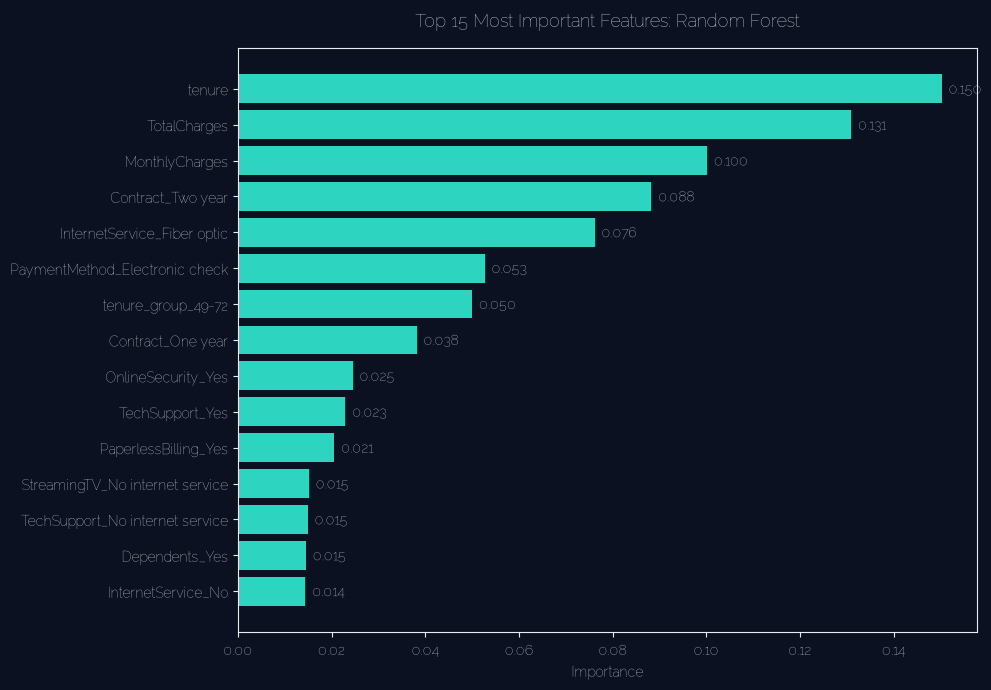

In [63]:
# Extract the importance of each feature according to Random Forest
# feature_importances_ returns a number for each column in X_train,
# indicating how much that variable contributed to the model's decisions
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Show the top 15 most important
top15 = importances.head(15)
print(top15.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(S3_BG)
ax.set_facecolor(S3_BG)

# Horizontal bar chart, sorted from highest to lowest importance
bars = ax.barh(top15['feature'][::-1], top15['importance'][::-1], color=S3_TEAL)

ax.set_title('Top 15 Most Important Features: Random Forest', 
             color=S3_TEXT, fontsize=13, pad=15)
ax.set_xlabel('Importance', color=S3_TEXT)
ax.tick_params(colors=S3_TEXT)
for spine in ax.spines.values():
    spine.set_color(S3_TEXT)

# Data labels at the end of each bar
for bar, val in zip(bars, top15['importance'][::-1]):
    ax.annotate(
        f'{val:.3f}',
        (val, bar.get_y() + bar.get_height()/2),
        ha='left', va='center',
        fontsize=10, color=S3_TEXT, fontweight='bold',
        xytext=(5, 0), textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 8. Conclusions

**Selected model:** Random Forest (best Recall and F1-Score)

**Final performance:**
- Recall: 79.1%, detects 8 out of 10 customers who actually churn
- ROC-AUC: 0.843, good discrimination capability

**Most predictive variables:** tenure, TotalCharges, MonthlyCharges, contract type (Two year) and internet type (Fiber optic), consistent with the findings from the initial EDA.

**Business recommendation:** prioritize retention campaigns for customers with low tenure, month-to-month contracts and fiber optic service, the highest-risk profile identified by the model.

In [64]:
import joblib

# Save the trained model to a .pkl file
# This allows reusing it later without having to retrain from scratch
joblib.dump(rf_model, '../data/churn_model_rf.pkl')
joblib.dump(scaler, '../data/scaler.pkl')  # in case Logistic Regression is used later too

print("Model saved successfully to data/churn_model_rf.pkl")

Model saved successfully to data/churn_model_rf.pkl
